# Image to Pencil Sketch Converter using OpenCV

In this mini-project I will demonstrate how to convert a regular image into a pencil sketch using Python and OpenCV.


Learning Outcomes:
- Basic image processing techniques
- Grayscale conversion
- Inversion and blurring
- Using image division for sketch effect

Import Libraries

In [6]:
!pip install opencv-python

   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   ---- ----------------------------------- 4.5/39.5 MB 24.4 MB/s eta 0:00:02
   ---------- ----------------------------- 10.2/39.5 MB 24.5 MB/s eta 0:00:02
   ---------------- ----------------------- 16.8/39.5 MB 27.1 MB/s eta 0:00:01
   ----------------------- ---------------- 23.6/39.5 MB 28.7 MB/s eta 0:00:01
   ------------------------------ --------- 30.1/39.5 MB 29.0 MB/s eta 0:00:01
   ------------------------------------- -- 36.7/39.5 MB 29.2 MB/s eta 0:00:01
   ---------------------------------------  39.3/39.5 MB 29.1 MB/s eta 0:00:01
   ---------------------------------------- 39.5/39.5 MB 24.9 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import cv2
import matplotlib.pyplot as plt

** Load and Display the Original Image **

We first read the image using OpenCV and convert it from BGR (OpenCV default) to RGB for correct display using matplotlib.


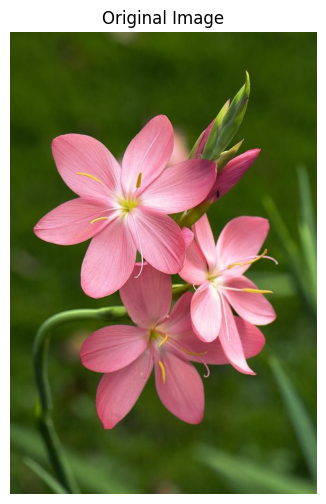

In [8]:
# Load your image (replace 'your_image.jpg' with your file)
image = cv2.imread('../Documents/ImagetoSketchdata.jpg')  
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB

# Show the original image
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')
plt.show()


Convert the Image to Grayscale

A sketch is essentially a monochrome drawing. Let's convert the image to grayscale.


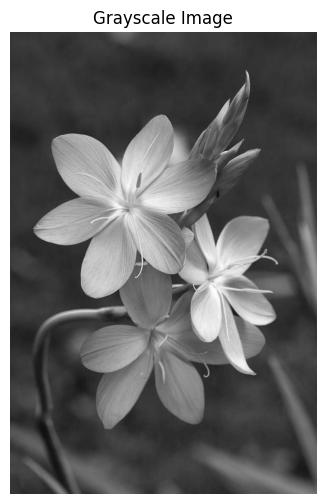

In [9]:
gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(6,6))
plt.imshow(gray_image, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()


Invert the Grayscale Image

We invert the grayscale image — dark becomes light and light becomes dark. This is used in the sketch creation step.


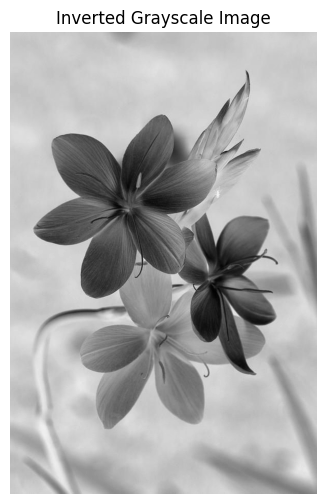

In [10]:
inverted_image = 255 - gray_image

plt.figure(figsize=(6,6))
plt.imshow(inverted_image, cmap='gray')
plt.title("Inverted Grayscale Image")
plt.axis('off')
plt.show()


Apply Gaussian Blur

Blurring smooths the image and removes noise. We'll use a Gaussian Blur with a large kernel size.


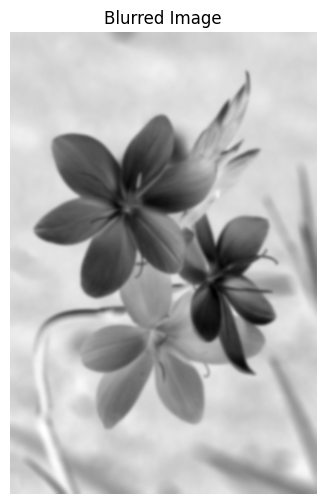

In [22]:
blurred = cv2.GaussianBlur(inverted_image, (15, 15), sigmaX=0, sigmaY=0)

plt.figure(figsize=(6,6))
plt.imshow(blurred, cmap='gray')
plt.title("Blurred Image")
plt.axis('off')
plt.show()


Create the Pencil Sketch

We now invert the blurred image and divide the grayscale image by this inverted blur. This gives a sketch-like effect.

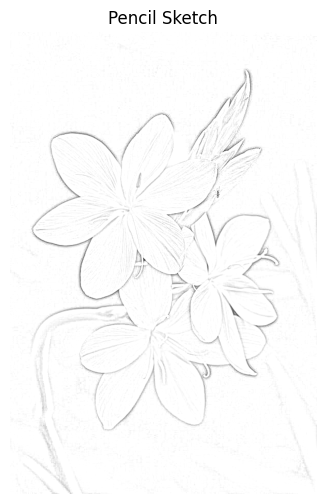

In [23]:
inverted_blurred = 255 - blurred
sketch = cv2.divide(gray_image, inverted_blurred, scale=256.0)

plt.figure(figsize=(6,6))
plt.imshow(sketch, cmap='gray')
plt.title("Pencil Sketch")
plt.axis('off')
plt.show()


applying a sharpening filter to enhance the outlines.

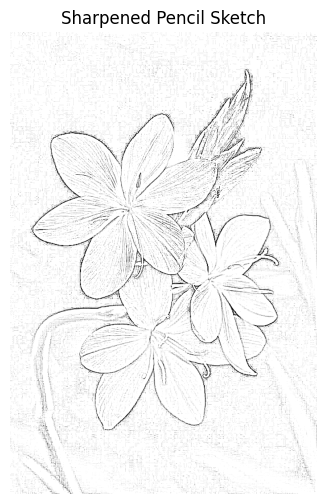

In [24]:
import numpy as np

# Define a sharpening kernel
sharpen_kernel = np.array([[-1, -1, -1],
                           [-1,  9, -1],
                           [-1, -1, -1]])

# Apply the sharpening
sharpened_sketch = cv2.filter2D(sketch, -1, sharpen_kernel)

# Display the sharpened sketch
plt.figure(figsize=(6,6))
plt.imshow(sharpened_sketch, cmap='gray')
plt.title("Sharpened Pencil Sketch")
plt.axis('off')
plt.show()
